In [15]:
import tensorflow as tf
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [2]:
# Load the DenseNet model pre-trained on ImageNet, excluding the top fully connected layers
base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

In [3]:
# Freeze the base model layers (optional, for fine-tuning)
for layer in base_model.layers:
    layer.trainable = False

In [4]:
# Add custom layers on top of the base DenseNet model
x = base_model.output
x = GlobalAveragePooling2D()(x)  # Global average pooling to reduce dimensions
x = Dense(1024, activation='relu')(x)  # Add a fully connected layer
x = Dense(512, activation='relu')(x)   # Another fully connected layer
x = Dense(128, activation='relu')(x)   # Another fully connected layer

# Output layer for binary classification
predictions = Dense(1, activation='sigmoid')(x)  # 1 output neuron for binary classification


In [5]:
# Combine the base model and the custom layers
model = Model(inputs=base_model.input, outputs=predictions)

In [6]:
# Compile the model with binary crossentropy for binary classification
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='binary_crossentropy',  # Binary classification loss function
              metrics=['accuracy'])

In [7]:
# Print the model summary
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 8,677,697 (33.10 MB)

 Trainable params: 1,640,193 (6.26 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [8]:
# Data augmentation and preprocessing
train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest')

In [9]:
val_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)


In [10]:
# Prepare the train and validation data generators
train_generator = train_datagen.flow_from_directory(
    'dataset/train',  # Path to your training dataset
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'  # Use binary for 2 classes
)

Found 1947 images belonging to 2 classes.


In [11]:
validation_generator = val_datagen.flow_from_directory(
    'dataset/validation',  # Path to your validation dataset
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'  # Use binary for 2 classes
)

Found 1947 images belonging to 2 classes.


In [12]:
# Train the model
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // validation_generator.batch_size,
    epochs=10  # You can adjust the number of epochs
)


Epoch 1/10


e:\DrBones\Dr_Bones\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


60/60 ━━━━━━━━━━━━━━━━━━━━ 243s 4s/step - accuracy: 0.6438 - loss: 0.6346 - val_accuracy: 0.7563 - val_loss: 0.4831
Epoch 2/10
 1/60 ━━━━━━━━━━━━━━━━━━━━ 1:16 1s/step - accuracy: 0.8148 - loss: 0.5903

D:\anaconda\Lib\contextlib.py:158: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.8148 - loss: 0.5903 - val_accuracy: 0.7407 - val_loss: 0.4230
Epoch 3/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 205s 3s/step - accuracy: 0.8065 - loss: 0.4731 - val_accuracy: 0.7953 - val_loss: 0.4561
Epoch 4/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.8438 - loss: 0.4293 - val_accuracy: 0.8148 - val_loss: 0.3950
Epoch 5/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 200s 3s/step - accuracy: 0.7928 - loss: 0.4667 - val_accuracy: 0.8062 - val_loss: 0.4284
Epoch 6/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.8438 - loss: 0.4375 - val_accuracy: 0.8148 - val_loss: 0.3833
Epoch 7/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 199s 3s/step - accuracy: 0.7932 - loss: 0.4417 - val_accuracy: 0.8188 - val_loss: 0.4093
Epoch 8/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.7812 - loss: 0.3897 - val_accuracy: 0.9630 - val_loss: 0.2721
Epoch 9/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 209s 3s/step - accuracy: 0.8258 - loss: 0.4030 - val_accuracy: 0.8281 - val_loss: 0.

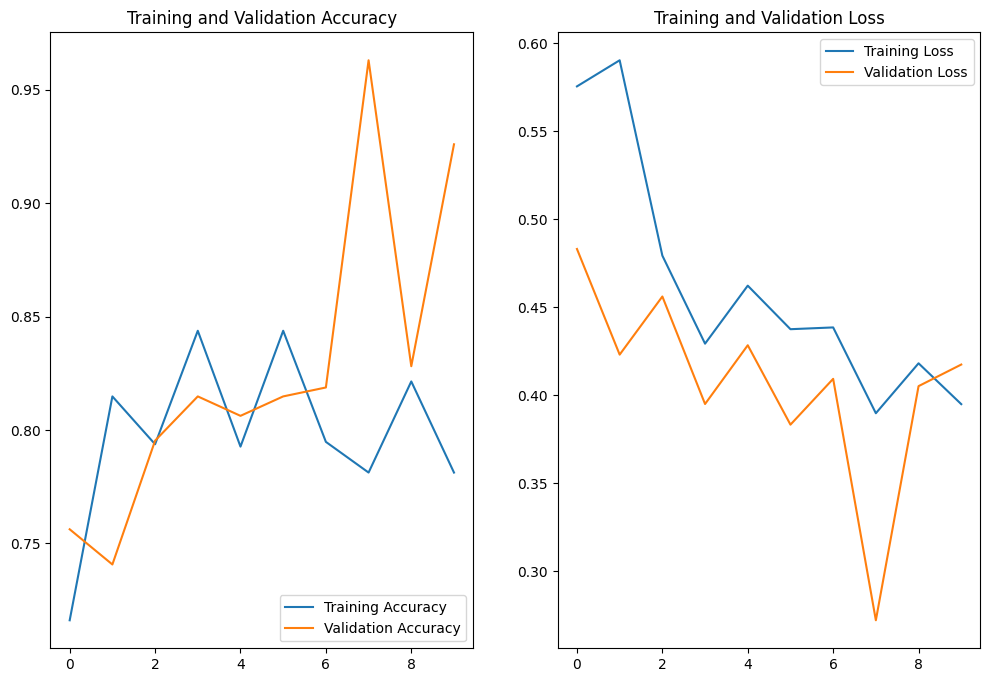

In [13]:

# Plot the training and validation accuracy and loss
def plot_training_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 8))

    # Plot accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')

    # Plot loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')

    plt.show()

# Call the function to plot the graphs
plot_training_history(history)